In [53]:
from astropy.table import Table

from tqdm import tqdm
from astropy import units as u

import numpy as np

import matplotlib.pyplot as plt
from astropy.constants import c

In [4]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves_v1/loa_rotvel_curvefit.fits')
loa_rotvel[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map,r_kpc,chi2_reduced,vmax_fit,rturn_fit,alpha_fit
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,2,0,3.312680244156565e-05,93.48259787088467,16.871398281910924,3.92031082335997e-05,0,0,5.4318001497347135,--,--,--,--
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,2,0,3.282385438171887e-05,85676.49697232743,16.492244492570364,4.3203103383505966e-05,0,0,2.193762544841905,--,--,--,--
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,2,0,0.00016285736718600513,298349.9880839603,61.441017847692045,0.00010611795301254078,1,1,2.09707125178735,--,--,--,--
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,2,0,0.00010525736360510445,318879.6974465264,47.24435675763793,0.00010611795301254078,1,1,2.0970712517870473,--,--,--,--
2389220349968384,67.92758592005009,-12.682644974455277,1.632425063296397,0.00018014046308523026,GALAXY,6.947847135365009,4,TFT,175172,S,0.007399622287542027,0.399999983148231,2,0,0.0001903381932319499,463859.8983985996,57.57010172761073,2.5458158785123104e-05,0,0,11.615514741142395,--,--,--,--


In [18]:
SGA = Table.read('/pscratch/sd/d/dbustos/rot_curves/sga_xmatch.fits')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,MASS_CG_5,MASSERR_CG_5
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,solMass,solMass
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0,--,--
3,SGA-2020 3,P

In [11]:
new_table = loa_rotvel[loa_rotvel['vmax_fit'] > 0]

In [21]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [24]:
G = 4.30091e-6

#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

In [49]:
l10_mass = []
log_cgmass = []

for i in tqdm(np.unique(new_table['SGA_ID'])[:50]):

    fibers = new_table['SGA_ID'] == i

    sga_id = SGA_dict[i]

    targs = new_table[fibers]
    
    vmax = targs['vmax_fit'][0]

    rturn = targs['rturn_fit'][0]

    r26_dist = .5 * SGA[sga_id]['D26']
    
    # distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    # convert deprojected dist from arcmin to radians
    theta = np.radians(r26_dist/60)

    # real distance from center of galaxy to fiber in units kpc/h
    r_fiber = (d_center * np.tan(theta) * 1000).value
    
    v_rot = vmax * np.tanh(r_fiber/rturn)
    
    mass = (v_rot**2)*(r_fiber)/G
    
    log_mass = np.log10(mass)

    cg_mass = SGA['MASS_CG_5'][sga_id]

    log_cg =  np.log10(cg_mass)

    # need to do mass error

    if (np.isfinite(log_mass)) and (np.isfinite(log_cg)):
        l10_mass += [log_mass]

        log_cgmass += [log_cg]

#     print('log mass: ', log_mass, 'log cg: ', np.log10(cg_mass))

# print(l10_mass)
# print(log_cgmass)

    # print('log mass: ', log_mass, 'log cg: ', np.log10(cg_mass))

    # print('cg mass', cg_mass)

    # print('logmass',log_mass)

# get velocity at r26

  0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_1697034/3180451221.py:35: RuntimeWarning: divide by zero encountered in log10
  log_cg =  np.log10(cg_mass)
/tmp/ipykernel_1697034/3180451221.py:31: RuntimeWarning: invalid value encountered in log10
  log_mass = np.log10(mass)
100%|██████████| 50/50 [00:00<00:00, 1337.75it/s]


Text(0.5, 1.0, 'stellar mass vs total mass')

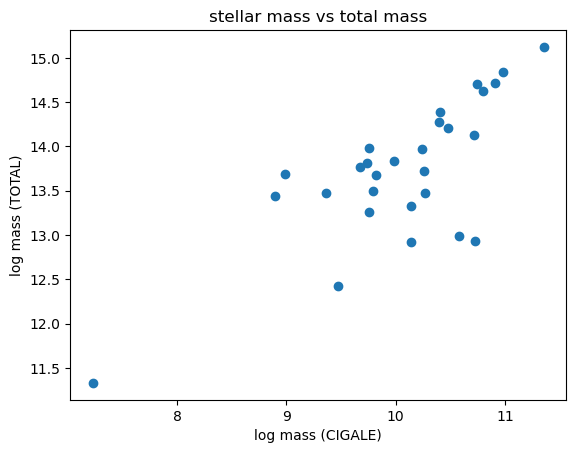

In [59]:
fig, ax = plt.subplots()

ax.scatter(log_cgmass, l10_mass)
ax.set_xlabel('log mass (CIGALE)')
ax.set_ylabel('log mass (TOTAL)')
ax.set_title('stellar mass vs total mass')